##### imports

In [7]:
import tensorflow as tf
import keras
from keras.saving import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers,models
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)
import reload_data2
#from google.colab import drive
#drive.mount('/content/drive')
import random
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

In [4]:
pd.read_csv("/content/Handwriting_Metadata_clean.csv").head()

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


## Data Loading

In [24]:
data_dir = "/content/Handwriting_Images"
IMAGE_SIZE=(442,442)
BATCH_SIZE=64
INPUT_SHAPE=(IMAGE_SIZE+(3,))
NUM_CLASSES=90

In [48]:
try:
    shutil.rmtree(data_dir)
    os.mkdir(data_dir)
except:
    pass

In [49]:
! unzip -q /content/Handwriting_Images_90sorted.zip

replace __MACOSX/._Handwriting_Images? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [25]:
new_data_dir = "New_Data"
os.mkdir(new_data_dir)

In [28]:
prompts = ["LND","PHR","WOZ"]

In [52]:
try:
    shutil.rmtree(new_data_dir)
    os.mkdir(new_data_dir)
except:
    pass

In [50]:
 #create folders for prompts & subfolders for writers under prompts
for writer in reload_data2.w_ids90:
    for prompt in prompts:
        os.makedirs(f"{data_dir}/{prompt}/{writer}",exist_ok=True)

#sort images according to prompt into writer subfolders
for writer in reload_data2.w_ids90:
    #iterate over every writer folder
    writer_path = f"{data_dir}/{writer}"
    #print(writer)
    #print(writer_path)

    #list of every image sample for writer
    samples = os.listdir(writer_path)

    #iterate over every image and move to writer subfolder under prompt folder
    for image in samples:
        image_path = f"{writer_path}/{image}" #path to specific image
        for prompt in prompts: #check every prompt
            if prompt in image:
                #move image to proper prompt folder under proper writer subfolder
                dest_path = f"{data_dir}/{prompt}/{writer}/{image}"
                shutil.move(image_path, dest_path)
                #print(f"MOVED: {image} to {prompt}")
                break
            else:
                continue
            #image isnt being classified at all
            print(f"ERROR: prompt not identified:\n{image}")

    shutil.rmtree(writer_path)

In [51]:
def process_image(args):
    img_path, output_path, target_size = args

    with Image.open(img_path) as img:
        img = img.convert("RGB")
        w, h = img.size
        max_dim = max(w, h)

        squared_img = Image.new("RGB", (max_dim, max_dim), (255,255,255))
        squared_img.paste(img, (0,0))

        if target_size:
            squared_img = squared_img.resize(target_size, Image.LANCZOS)

        squared_img.save(output_path)

def process_dataset(input_root, output_root, target_size=None, workers=8):

    tasks = []

    for split in prompts:
        split_path = os.path.join(input_root, split)

        for class_name in os.listdir(split_path):

            class_path = os.path.join(split_path, class_name)
            if not os.path.isdir(class_path):
                continue

            output_class_path = os.path.join(output_root, split, class_name)
            os.makedirs(output_class_path, exist_ok=True)

            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png','.jpg','.jpeg')):

                    img_path = os.path.join(class_path, img_name)
                    output_path = os.path.join(output_class_path, img_name)

                    tasks.append((img_path, output_path, target_size))

    with ProcessPoolExecutor(max_workers=workers) as executor:
        list(tqdm(executor.map(process_image, tasks), total=len(tasks)))

In [53]:
%%time
process_dataset(data_dir, new_data_dir, target_size=IMAGE_SIZE)

100%|██████████| 2430/2430 [01:10<00:00, 34.43it/s]

CPU times: user 1.47 s, sys: 545 ms, total: 2.02 s
Wall time: 1min 10s


# Consistent Split

In [56]:
random.shuffle(prompts)

train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{new_data_dir}/{prompts[0]}",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{new_data_dir}/{prompts[1]}",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
test_ds = tf.keras.utils.image_dataset_from_directory(
        f"{new_data_dir}/{prompts[2]}",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)
test_ds = test_ds.prefetch(tf_data.AUTOTUNE)

Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.


In [62]:
prompts

['LND', 'PHR', 'WOZ']

## Model building

In [57]:
base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=INPUT_SHAPE
                        )

model = reload_data2.make_transfer_model(base_model,input_shape=INPUT_SHAPE,
                                         num_classes=NUM_CLASSES,
                                         name="mobilenet_thirds2")
model.summary()

/tmp/ipykernel_816/3575937985.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Model: "mobilenet_thirds2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 14, 14, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## epochs

In [58]:
%%time

epochs = 80

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), ###make sure is true
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("MobileNetV2_thirds2.keras")

Epoch 1/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - acc: 0.0099 - loss: 4.7962 - top3_acc: 0.0309 - val_acc: 0.0185 - val_loss: 4.6502 - val_top3_acc: 0.0420
Epoch 2/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - acc: 0.0481 - loss: 4.3163 - top3_acc: 0.0963 - val_acc: 0.0086 - val_loss: 4.7121 - val_top3_acc: 0.0407
Epoch 3/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - acc: 0.0951 - loss: 3.9853 - top3_acc: 0.2025 - val_acc: 0.0222 - val_loss: 4.7274 - val_top3_acc: 0.0370
Epoch 4/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - acc: 0.1543 - loss: 3.7278 - top3_acc: 0.3222 - val_acc: 0.0099 - val_loss: 4.9132 - val_top3_acc: 0.0370
Epoch 5/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - acc: 0.2000 - loss: 3.4940 - top3_acc: 0.4037 - val_acc: 0.0173 - val_loss: 5.0435 - val_top3_acc: 0.0395
Epoch 6/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - acc: 0.2605 - loss: 3.3351 - top3_acc: 0.4654 - val_acc: 0.0136 - val_loss: 5.1584 - val_top3_acc: 0.0432
Epoch 7/80
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/s

In [59]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"thirds2_lossacc.csv")

### Visualization

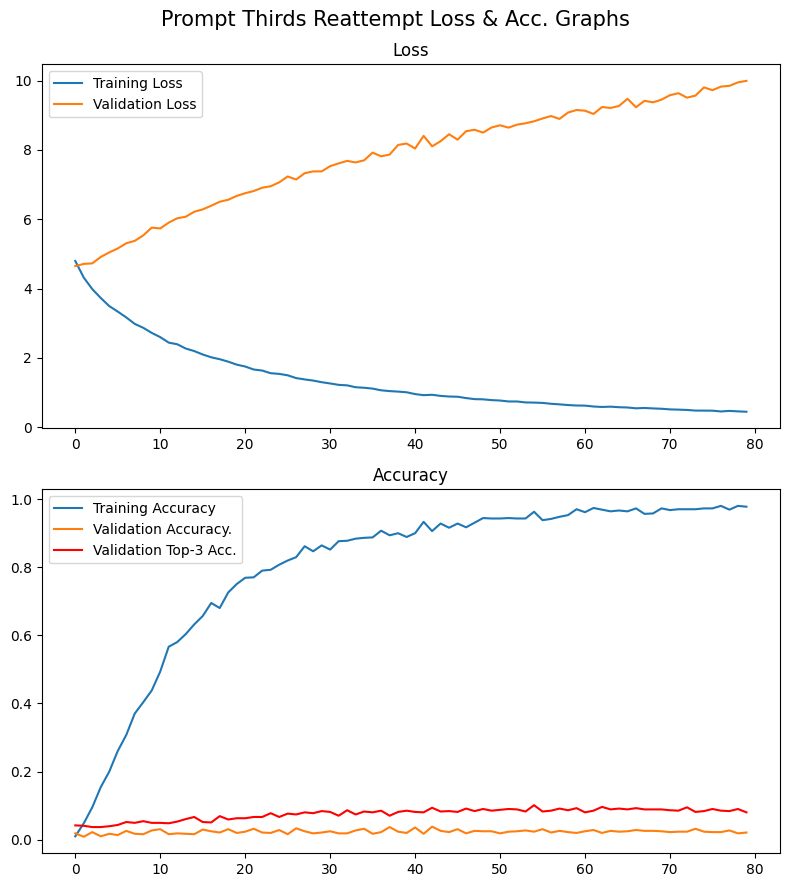

In [60]:
plt.figure(figsize=(8,9))
plt.suptitle("Prompt Thirds Reattempt Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [61]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.6938 - loss: 1.3020 - top3_acc: 0.8543
{'acc': 0.6938271522521973, 'loss': 1.3020195960998535, 'top3_acc': 0.8543210029602051}


    val did not do well but test did??

Probably due to val being `PHR`

- prediction accuracy disparity between prompts in "normal" models?
    - e.g., is `PHR` under-predicted?

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


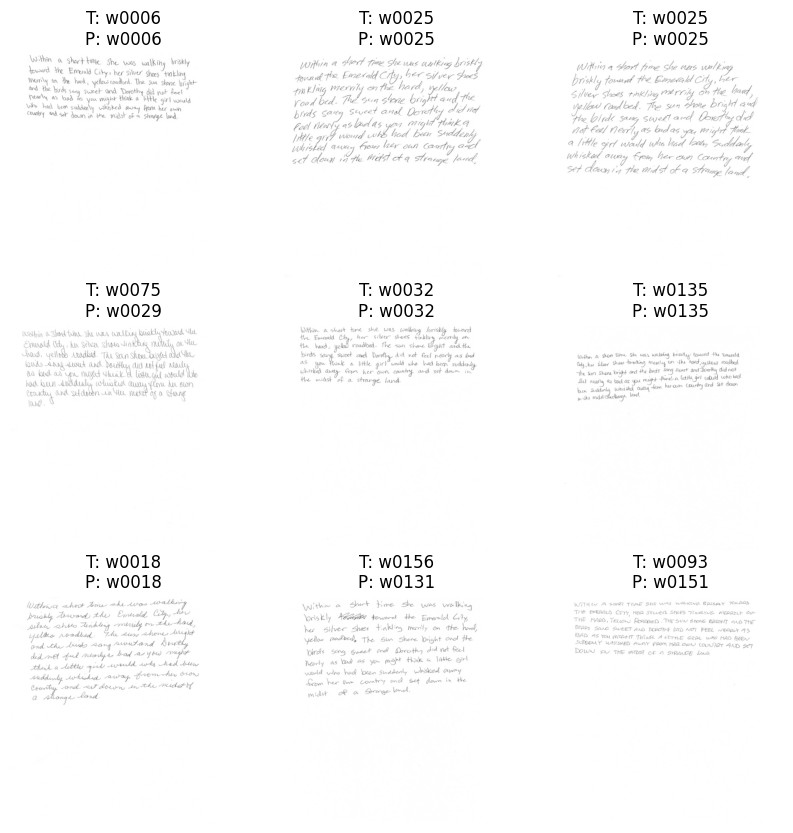

In [64]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = reload_data2.w_ids90[labels[i]]
        pred_label = reload_data2.w_ids90[pred_labels[i]]
        plt.title(f"T: {true_label}\nP: {pred_label}")
        plt.axis("off")
    plt.show()

# Randomized

In [65]:
w_ids=reload_data2.w_ids90

In [66]:
#recreate writer folders
for writer in w_ids:
    os.mkdir(f"{data_dir}/{writer}")

for prompt in prompts:
    for writer in w_ids:
        shutil.move(f"{data_dir}/{prompt}/{writer}",f"{data_dir}/{writer}/{prompt}")

os.mkdir(f"{data_dir}/train")
os.mkdir(f"{data_dir}/val")
os.mkdir(f"{data_dir}/test")

NameError: name 'data_folder_path' is not defined

In [68]:
for writer in w_ids:
    ind=random.randint(0,2)

    train_subfolder = f"{data_dir}/{writer}/{prompts[ind]}"
    #os.makedirs(train_subfolder,exist_ok=True)
    shutil.move(train_subfolder,f"{data_dir}/train/{writer}")

    val_subfolder = f"{data_dir}/{writer}/{prompts[(ind+1)%3]}"
    #os.makedirs(val_subfolder,exist_ok=True)
    shutil.move(val_subfolder,f"{data_dir}/val/{writer}")

    test_subfolder = f"{data_dir}/{writer}/{prompts[(ind+2)%3]}"
    #os.makedirs(test_subfolder,exist_ok=True)
    shutil.move(test_subfolder,f"{data_dir}/test/{writer}")

In [69]:
def process_image(args):
    img_path, output_path, target_size = args

    with Image.open(img_path) as img:
        img = img.convert("RGB")
        w, h = img.size
        max_dim = max(w, h)

        squared_img = Image.new("RGB", (max_dim, max_dim), (255,255,255))
        squared_img.paste(img, (0,0))

        if target_size:
            squared_img = squared_img.resize(target_size, Image.LANCZOS)

        squared_img.save(output_path)

def process_dataset(input_root, output_root, target_size=None, workers=8):

    tasks = []

    for split in ["train","val","test"]:
        split_path = os.path.join(input_root, split)

        for class_name in os.listdir(split_path):

            class_path = os.path.join(split_path, class_name)
            if not os.path.isdir(class_path):
                continue

            output_class_path = os.path.join(output_root, split, class_name)
            os.makedirs(output_class_path, exist_ok=True)

            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png','.jpg','.jpeg')):

                    img_path = os.path.join(class_path, img_name)
                    output_path = os.path.join(output_class_path, img_name)

                    tasks.append((img_path, output_path, target_size))

    with ProcessPoolExecutor(max_workers=workers) as executor:
        list(tqdm(executor.map(process_image, tasks), total=len(tasks)))

In [71]:
try:
    shutil.rmtree(new_data_dir)
    os.mkdir(new_data_dir)
except:
    pass

In [72]:
%%time
process_dataset(data_dir, new_data_dir, target_size=IMAGE_SIZE)

100%|██████████| 2430/2430 [01:05<00:00, 37.18it/s]

CPU times: user 1.59 s, sys: 604 ms, total: 2.19 s
Wall time: 1min 5s


In [73]:
train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{new_data_dir}/train",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{new_data_dir}/val",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
test_ds = tf.keras.utils.image_dataset_from_directory(
        f"{new_data_dir}/test",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)
test_ds = test_ds.prefetch(tf_data.AUTOTUNE)

Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.


In [74]:
help(reload_data2.make_transfer_model)

Help on function make_transfer_model in module reload_data2:

make_transfer_model(base_model, input_shape, num_classes, name)



## Modelling

In [77]:
model=reload_data2.make_transfer_model(base_model,INPUT_SHAPE,NUM_CLASSES,"mobilenet_thirds2_random")

In [78]:
model.summary()

Model: "mobilenet_thirds2_random"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 14, 14, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### epochs

In [87]:
%%time

epochs = 75

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), ###make sure is true
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

#early_stopping = keras.callbacks.EarlyStopping(
#    monitor='val_acc',   # Metric to monitor (e.g., validation loss)
#    patience=10,           # Number of epochs with no improvement after which training will be stopped
#    min_delta=0.01,      # Minimum change to qualify as an improvement
#    mode='max',
#    verbose=1,            # Log messages when the callback acts
#    restore_best_weights=True # Restores the best model weights
#    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds,
    #callbacks=[early_stopping]
    )

model.save("MobileNetV2_thirds2_random.keras")

Epoch 1/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - acc: 0.7531 - loss: 1.4101 - top3_acc: 0.8938 - val_acc: 0.2296 - val_loss: 5.3834 - val_top3_acc: 0.3222
Epoch 2/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - acc: 0.7704 - loss: 1.3373 - top3_acc: 0.9247 - val_acc: 0.2432 - val_loss: 5.4264 - val_top3_acc: 0.3296
Epoch 3/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - acc: 0.8086 - loss: 1.2354 - top3_acc: 0.9346 - val_acc: 0.2210 - val_loss: 5.4871 - val_top3_acc: 0.3235
Epoch 4/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - acc: 0.8333 - loss: 1.1825 - top3_acc: 0.9457 - val_acc: 0.2395 - val_loss: 5.5040 - val_top3_acc: 0.3247
Epoch 5/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - acc: 0.8519 - loss: 1.1472 - top3_acc: 0.9506 - val_acc: 0.2284 - val_loss: 5.5475 - val_top3_acc: 0.3272
Epoch 6/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - acc: 0.8420 - loss: 1.1013 - top3_acc: 0.9543 - val_acc: 0.2457 - val_loss: 5.6014 - val_top3_acc: 0.3296
Epoch 7/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/s

In [88]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"thirds2_random_lossacc.csv")

### Visualization

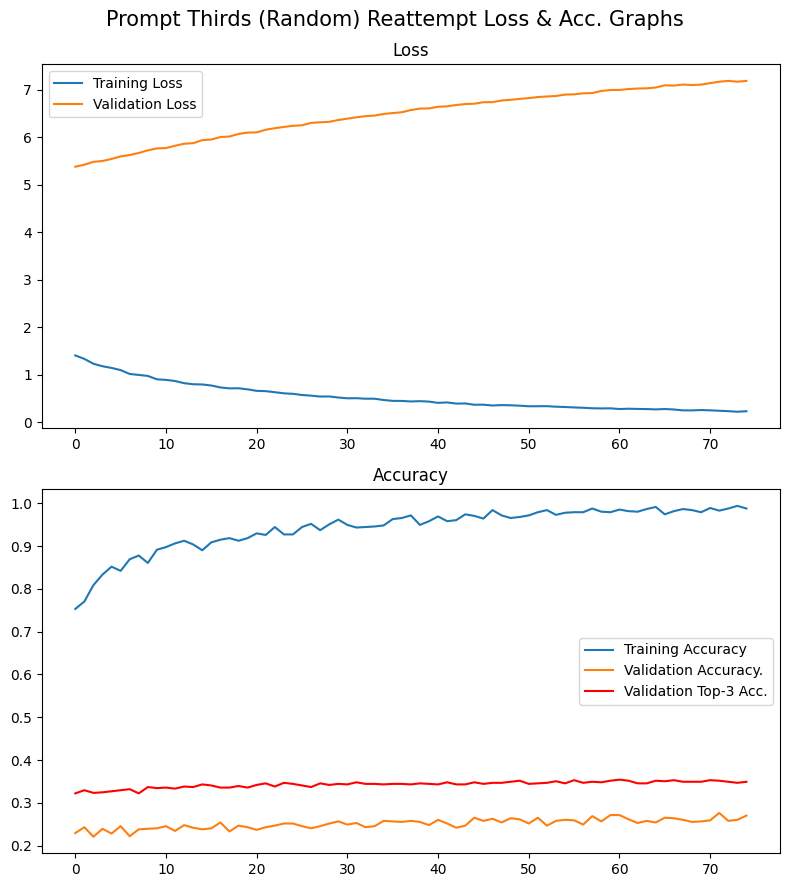

In [89]:
plt.figure(figsize=(8,9))
plt.suptitle("Prompt Thirds (Random) Reattempt Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [90]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.2407 - loss: 6.0782 - top3_acc: 0.3160
{'acc': 0.24074074625968933, 'loss': 6.078221321105957, 'top3_acc': 0.31604939699172974}


    ^ performed worse

- splitting by prompt likely reduces intra-class variability
    - e.g., if a class trains on `PHR`, model might learn that the author's writing is short

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


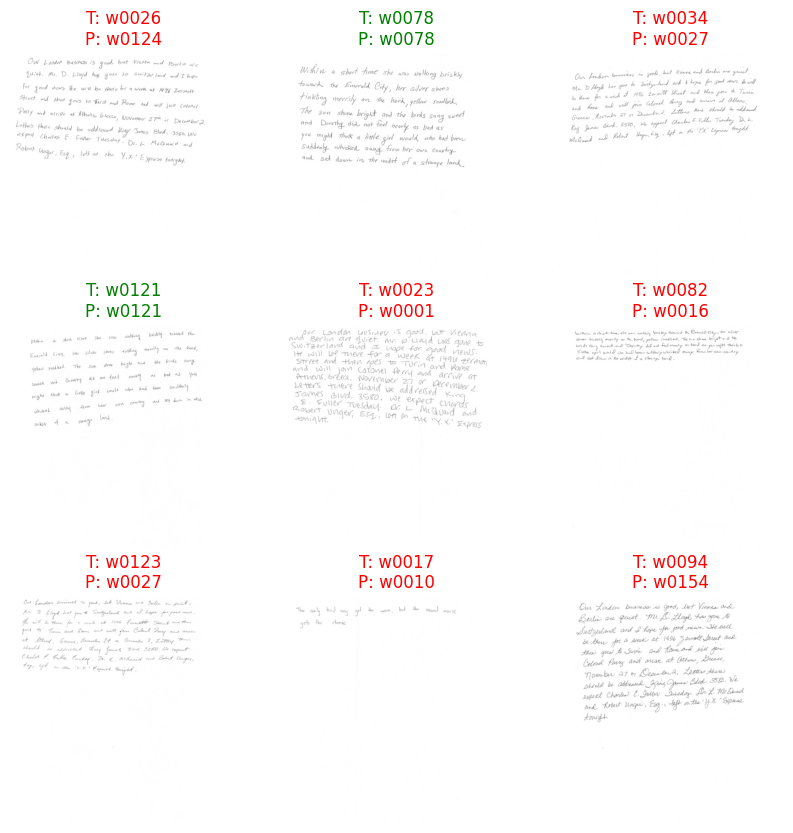

In [93]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = reload_data2.w_ids90[labels[i]]
        pred_label = reload_data2.w_ids90[pred_labels[i]]
        if true_label == pred_label:
            c = "green"
        else:
            c="red"
        plt.title(f"T: {true_label}\nP: {pred_label}",color=c)
        plt.axis("off")
    plt.show()